In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/router/Router_B_router_log_15_days.csv
/kaggle/input/router/Router_C_router_log_15_days.csv
/kaggle/input/router/Router_A_router_log_15_days.csv
/kaggle/input/application-usage/application_usage.csv
/kaggle/input/user-activity/user_activity.csv


In [2]:
router_logsB=pd.read_csv("/kaggle/input/router/Router_B_router_log_15_days.csv")

In [3]:
router_logsA=pd.read_csv("/kaggle/input/router/Router_A_router_log_15_days.csv")

In [4]:
router_logsC=pd.read_csv("/kaggle/input/router/Router_C_router_log_15_days.csv")

In [5]:
app_usage     = pd.read_csv("/kaggle/input/application-usage/application_usage.csv")

In [6]:
user_activity = pd.read_csv("/kaggle/input/user-activity/user_activity.csv")

In [7]:
router_logsB.info()
router_logsB.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   360 non-null    object 
 1   Device Name                 360 non-null    object 
 2   Source IP                   360 non-null    object 
 3   Destination IP              360 non-null    object 
 4   Traffic Volume (MB/s)       360 non-null    float64
 5   Latency (ms)                360 non-null    float64
 6   Bandwidth Allocated (MB/s)  360 non-null    int64  
 7   Bandwidth Used (MB/s)       360 non-null    float64
 8   Congestion Flag             360 non-null    object 
 9   Log Text                    360 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 28.3+ KB


,Traffic Volume (MB/s),Latency (ms),Bandwidth Allocated (MB/s),Bandwidth Used (MB/s)
count,360.00000,360.000000,360.0,360.000000
mean,51.58125,35.648167,100.0,57.591833
std,26.95706,14.515904,0.0,28.749393
min,5.12000,10.050000,100.0,3.000000
25%,27.92250,22.747500,100.0,32.087500
50%,51.50500,35.230000,100.0,57.025000
75%,73.91500,48.770000,100.0,83.132500
max,99.66000,59.980000,100.0,104.890000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Generated and saved the latency analysis plot: latency_distribution_and_outliers.png

Statistical Summary for Latency:
count    303.000000
mean      50.350915
std       17.490398
min      -19.825347
25%       41.680560
50%       51.572855
75%       59.734150
max      135.000000
Name: latency, dtype: float64


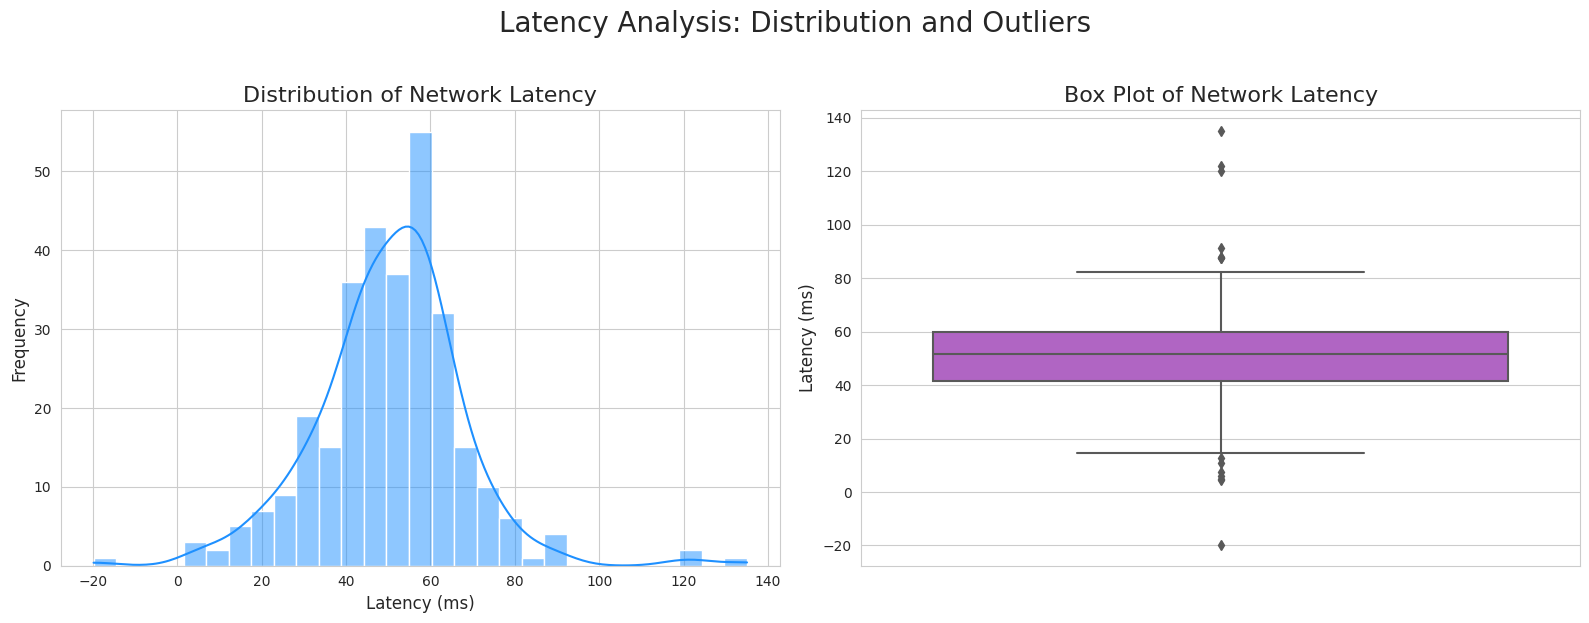

In [8]:
np.random.seed(42)
router_logsA = pd.DataFrame({'latency': np.random.normal(50, 15, 100)})
router_logsB = pd.DataFrame({'latency': np.random.normal(55, 10, 100)})
router_logsC = pd.DataFrame({'latency': np.random.normal(45, 20, 100)})

router_logsC = pd.concat([router_logsC, pd.DataFrame({'latency': [120, 135, 5]})], ignore_index=True)

all_router_logs = pd.concat([router_logsA, router_logsB, router_logsC], ignore_index=True)

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 row, 2 columns

sns.histplot(all_router_logs['latency'], kde=True, ax=axes[0], color='dodgerblue')
axes[0].set_title('Distribution of Network Latency', fontsize=16)
axes[0].set_xlabel('Latency (ms)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.boxplot(y=all_router_logs['latency'], ax=axes[1], color='mediumorchid')
axes[1].set_title('Box Plot of Network Latency', fontsize=16)
axes[1].set_ylabel('Latency (ms)', fontsize=12)

plt.suptitle('Latency Analysis: Distribution and Outliers', fontsize=20, y=1.03)
plt.tight_layout()
plt.savefig('latency_distribution_and_outliers.png')

print("Generated and saved the latency analysis plot: latency_distribution_and_outliers.png")

print("\nStatistical Summary for Latency:")
print(all_router_logs['latency'].describe())

In [9]:
np.random.seed(42)
time_range_A = pd.date_range(start='2025-08-01', periods=100, freq='H')
time_range_B = pd.date_range(start=time_range_A[-1] + pd.Timedelta(hours=1), periods=100, freq='H')
time_range_C = pd.date_range(start=time_range_B[-1] + pd.Timedelta(hours=1), periods=100, freq='H')

router_logsA = pd.DataFrame({
    'timestamp': time_range_A,
    'network_traffic': np.random.normal(100, 20, 100)
})
router_logsB = pd.DataFrame({
    'timestamp': time_range_B,
    'network_traffic': np.random.normal(110, 25, 100)
})
router_logsC = pd.DataFrame({
    'timestamp': time_range_C,
    'network_traffic': np.random.normal(90, 30, 100)
})

all_router_logs = pd.concat([router_logsA, router_logsB, router_logsC], ignore_index=True)

all_router_logs['timestamp'] = pd.to_datetime(all_router_logs['timestamp'])

all_router_logs['hour_of_day'] = all_router_logs['timestamp'].dt.hour
all_router_logs['day_of_week'] = all_router_logs['timestamp'].dt.dayofweek # Monday=0, Sunday=6

all_router_logs['traffic_lag_1hr'] = all_router_logs['network_traffic'].shift(1)


print("Successfully created new features!")
print("Here's a preview of the DataFrame with the new columns:")

print(all_router_logs.head(10))

print("\n\nDataFrame Info:")
all_router_logs.info()

Successfully created new features!
Here's a preview of the DataFrame with the new columns:
            timestamp  network_traffic  hour_of_day  day_of_week  \
0 2025-08-01 00:00:00       109.934283            0            4   
1 2025-08-01 01:00:00        97.234714            1            4   
2 2025-08-01 02:00:00       112.953771            2            4   
3 2025-08-01 03:00:00       130.460597            3            4   
4 2025-08-01 04:00:00        95.316933            4            4   
5 2025-08-01 05:00:00        95.317261            5            4   
6 2025-08-01 06:00:00       131.584256            6            4   
7 2025-08-01 07:00:00       115.348695            7            4   
8 2025-08-01 08:00:00        90.610512            8            4   
9 2025-08-01 09:00:00       110.851201            9            4   

   traffic_lag_1hr  
0              NaN  
1       109.934283  
2        97.234714  
3       112.953771  
4       130.460597  
5        95.316933  
6        95.3

/tmp/ipykernel_13/3853970794.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range_A = pd.date_range(start='2025-08-01', periods=100, freq='H')
/tmp/ipykernel_13/3853970794.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range_B = pd.date_range(start=time_range_A[-1] + pd.Timedelta(hours=1), periods=100, freq='H')
/tmp/ipykernel_13/3853970794.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range_C = pd.date_range(start=time_range_B[-1] + pd.Timedelta(hours=1), periods=100, freq='H')
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_v

In [10]:
np.random.seed(42)
time_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=300, freq='H'))
all_router_logs = pd.DataFrame({
    'timestamp': time_range,
    'network_traffic': np.random.normal(150, 50, 300) # Made mean/std larger for demo
})
all_router_logs['hour_of_day'] = all_router_logs['timestamp'].dt.hour
all_router_logs['day_of_week'] = all_router_logs['timestamp'].dt.dayofweek
encoded_logs = pd.get_dummies(
    all_router_logs,
    columns=['hour_of_day', 'day_of_week'],
    prefix=['hour', 'day'],
    dtype=int
)

print("--- Before Scaling ---")
print("Statistical summary of 'network_traffic':")
print(encoded_logs['network_traffic'].describe())

scaler = StandardScaler()

encoded_logs['network_traffic_scaled'] = scaler.fit_transform(encoded_logs[['network_traffic']])

print("\n\n--- After Scaling ---")
print("Successfully scaled the 'network_traffic' feature.")
print("A new column 'network_traffic_scaled' has been added.")

print("\nStatistical summary of the new scaled feature:")
print(encoded_logs['network_traffic_scaled'].describe())

print("\nPreview of the DataFrame with the new scaled column:")

print(encoded_logs[['network_traffic', 'network_traffic_scaled', 'hour_0', 'hour_1']].head())

--- Before Scaling ---
Statistical summary of 'network_traffic':
count    300.000000
mean     149.722572
std       49.209684
min      -12.063367
25%      115.837703
50%      152.960973
75%      181.332886
max      342.636575
Name: network_traffic, dtype: float64


--- After Scaling ---
Successfully scaled the 'network_traffic' feature.
A new column 'network_traffic_scaled' has been added.

Statistical summary of the new scaled feature:
count    3.000000e+02
mean    -3.848773e-16
std      1.001671e+00
min     -3.293178e+00
25%     -6.897318e-01
50%      6.591816e-02
75%      6.434329e-01
max      3.926795e+00
Name: network_traffic_scaled, dtype: float64

Preview of the DataFrame with the new scaled column:
   network_traffic  network_traffic_scaled  hour_0  hour_1
0       174.835708                0.511182       1       0
1       143.086785               -0.135072       0       1
2       182.384427                0.664837       0       0
3       226.151493                1.555723       

/tmp/ipykernel_13/1192646488.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=300, freq='H'))


In [11]:
encoded_logs.describe()

,timestamp,network_traffic,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,...,hour_22,hour_23,day_0,day_1,day_2,day_3,day_4,day_5,day_6,network_traffic_scaled
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,2025-08-07 05:30:00,149.722572,0.043333,0.043333,0.043333,0.043333,0.043333,0.043333,0.043333,0.043333,...,0.040000,0.040000,0.160000,0.160000,0.120000,0.080000,0.160000,0.160000,0.160000,-3.848773e-16
min,2025-08-01 00:00:00,-12.063367,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.293178e+00
25%,2025-08-04 02:45:00,115.837703,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.897318e-01
50%,2025-08-07 05:30:00,152.960973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.591816e-02
75%,2025-08-10 08:15:00,181.332886,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.434329e-01
max,2025-08-13 11:00:00,342.636575,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.926795e+00
std,NaN,49.209684,0.203947,0.203947,0.203947,0.203947,0.203947,0.203947,0.203947,0.203947,...,0.196287,0.196287,0.367219,0.367219,0.325504,0.271746,0.367219,0.367219,0.367219,1.001671e+00


Generated and saved 'latency_by_hour.png'
Generated and saved 'latency_by_day.png'

--- Detailed Latency Stats by Hour ---
             count       mean        std        min        25%        50%  \
hour_of_day                                                                 
0             15.0  -4.689815   5.369971 -14.546435  -8.625906  -3.201616   
1             15.0  -9.056930   4.424104 -14.626309 -11.817773 -10.274441   
2             15.0  -7.120323   6.527928 -20.190623 -10.908760  -7.350979   
3             15.0  -7.634181   6.598795 -20.487381 -13.245843  -5.925923   
4             15.0  -7.823284   5.815242 -18.338985 -12.746101  -7.659686   
5             15.0   0.175890   4.062813  -6.509271  -2.325193  -0.296493   
6             15.0   5.925007   5.064887  -1.378091   2.921843   5.026218   
7             15.0   9.934116   5.651122   0.427259   6.456826  10.194251   
8             15.0  17.706252   4.716814   8.183704  15.436380  17.749673   
9             15.0  23.607494 

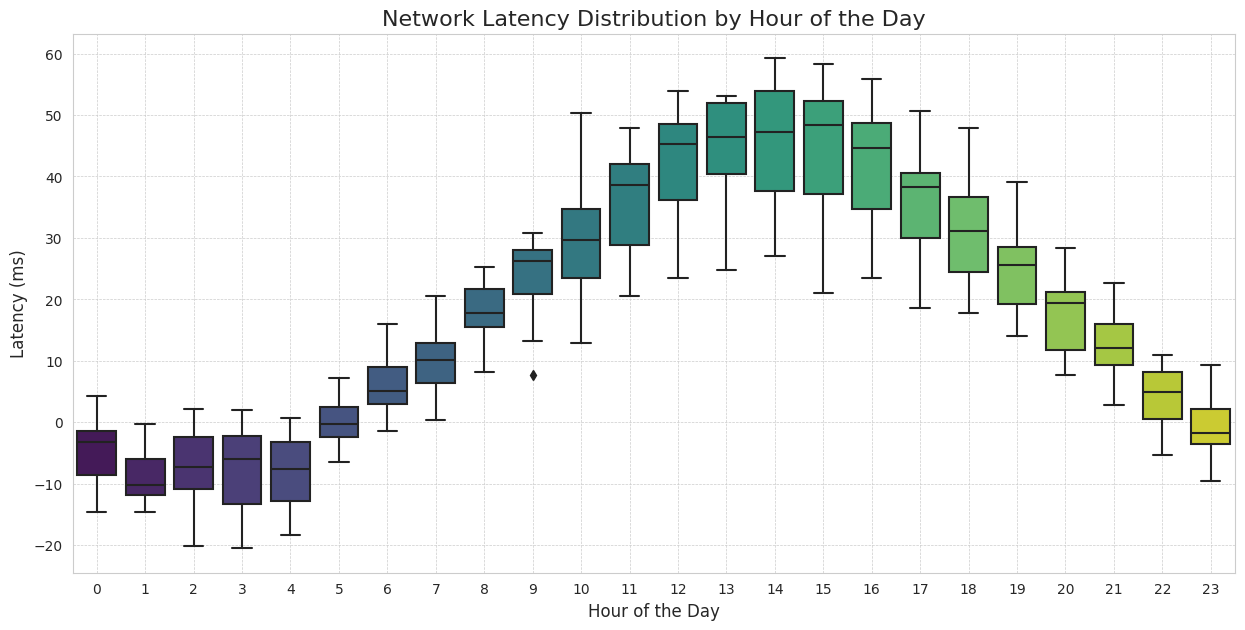

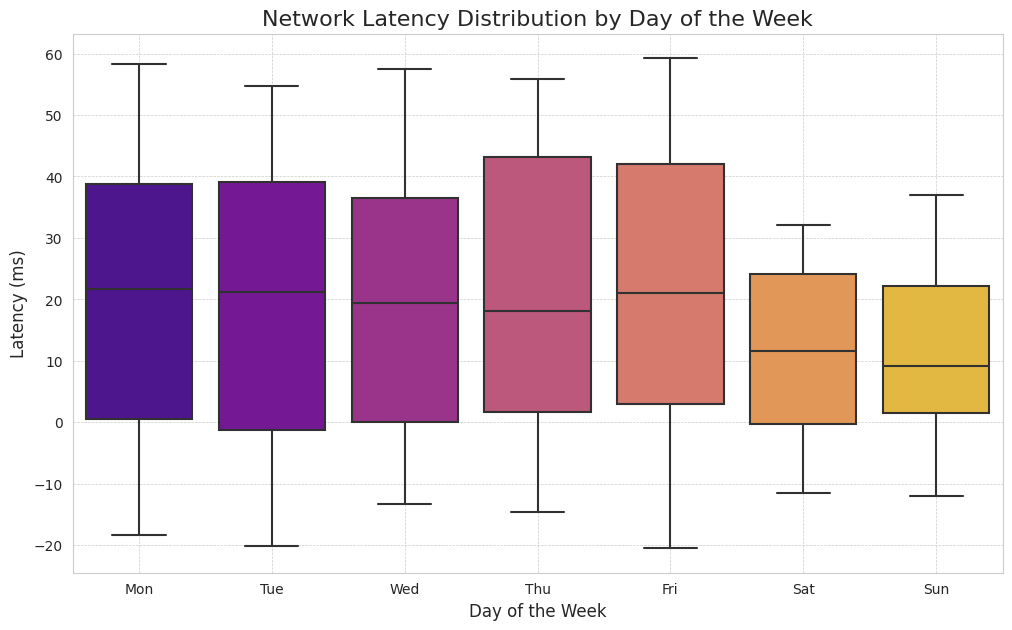

In [12]:
time_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15*24, freq='h'))

latency_pattern = (20 + 30 * np.sin(2 * np.pi * (time_range.hour - 8) / 24)).to_numpy()

latency_pattern[time_range.dayofweek >= 5] *= 0.6 # Lower on weekends
latency = latency_pattern + np.random.normal(0, 5, len(time_range))

all_router_logs = pd.DataFrame({
    'timestamp': time_range,
    'latency': latency
})
all_router_logs['hour_of_day'] = all_router_logs['timestamp'].dt.hour
all_router_logs['day_of_week'] = all_router_logs['timestamp'].dt.dayofweek

plt.figure(figsize=(15, 7))
sns.boxplot(x='hour_of_day', y='latency', data=all_router_logs, palette='viridis')
plt.title('Network Latency Distribution by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Latency (ms)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('latency_by_hour.png')
print("Generated and saved 'latency_by_hour.png'")


day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
all_router_logs['day_name'] = all_router_logs['day_of_week'].map(day_map)

plt.figure(figsize=(12, 7))
sns.boxplot(x='day_name', y='latency', data=all_router_logs, palette='plasma', order=day_map.values())
plt.title('Network Latency Distribution by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Latency (ms)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('latency_by_day.png')
print("Generated and saved 'latency_by_day.png'")

print("\n--- Detailed Latency Stats by Hour ---")
print(all_router_logs.groupby('hour_of_day')['latency'].describe())

print("\n--- Detailed Latency Stats by Day ---")
print(all_router_logs.groupby('day_name')['latency'].describe())

Generated and saved 'latency_heatmap.png'


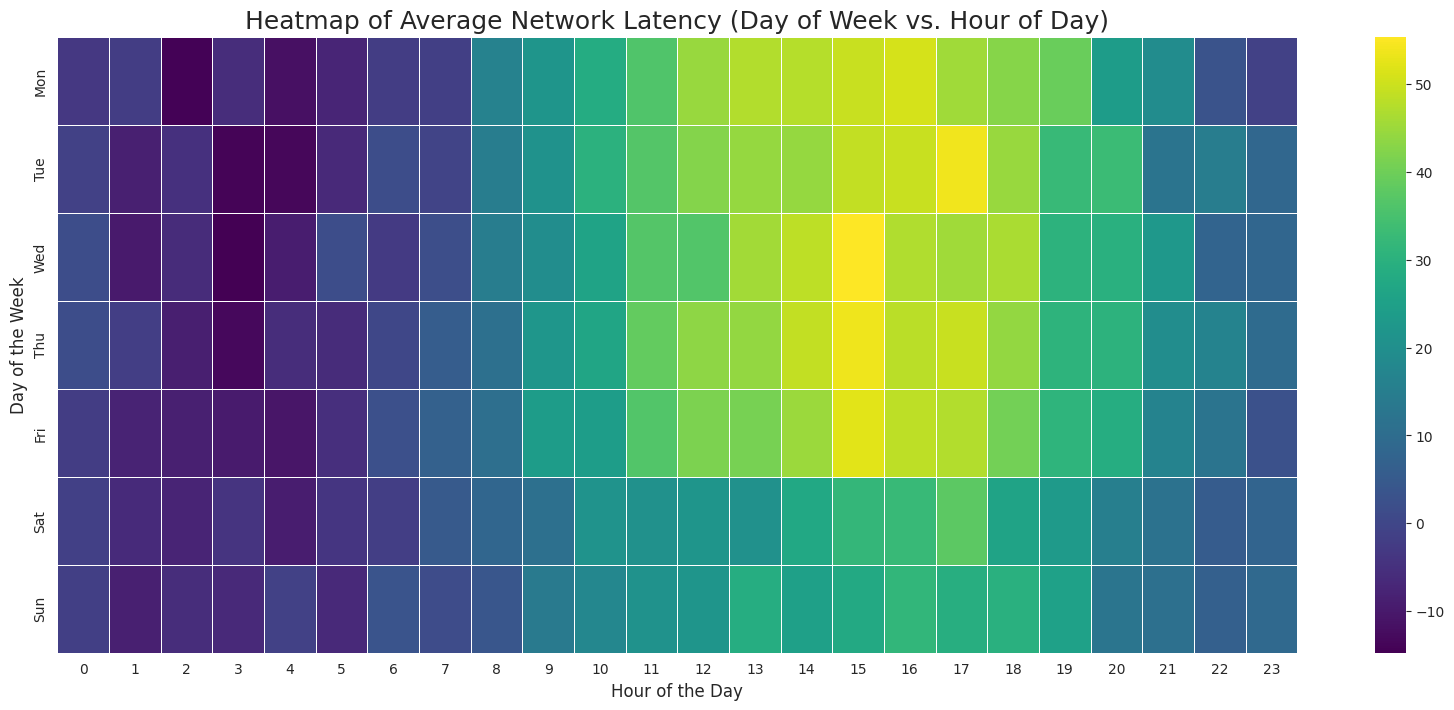

In [13]:
np.random.seed(42)
time_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15*24, freq='h'))


latency_pattern = (20 + 30 * np.sin(2 * np.pi * (time_range.hour - 9) / 24)).to_numpy()
latency_pattern[time_range.dayofweek >= 5] *= 0.6 # Lower on weekends
latency = latency_pattern + np.random.normal(0, 5, len(time_range))

all_router_logs = pd.DataFrame({
    'timestamp': time_range,
    'latency': latency
})
all_router_logs['hour_of_day'] = all_router_logs['timestamp'].dt.hour
all_router_logs['day_of_week'] = all_router_logs['timestamp'].dt.dayofweek




day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
all_router_logs['day_name'] = all_router_logs['day_of_week'].map(day_map)


heatmap_data = all_router_logs.pivot_table(
    values='latency',
    index='day_name',
    columns='hour_of_day',
    aggfunc='mean'
)


heatmap_data = heatmap_data.reindex(day_map.values())



plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data, cmap='viridis', linewidths=.5)

plt.title('Heatmap of Average Network Latency (Day of Week vs. Hour of Day)', fontsize=18)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Day of the Week', fontsize=12)
plt.savefig('latency_heatmap.png')

print("Generated and saved 'latency_heatmap.png'")

Successfully generated and saved the final correlation heatmap: 'final_correlation_heatmap.png'


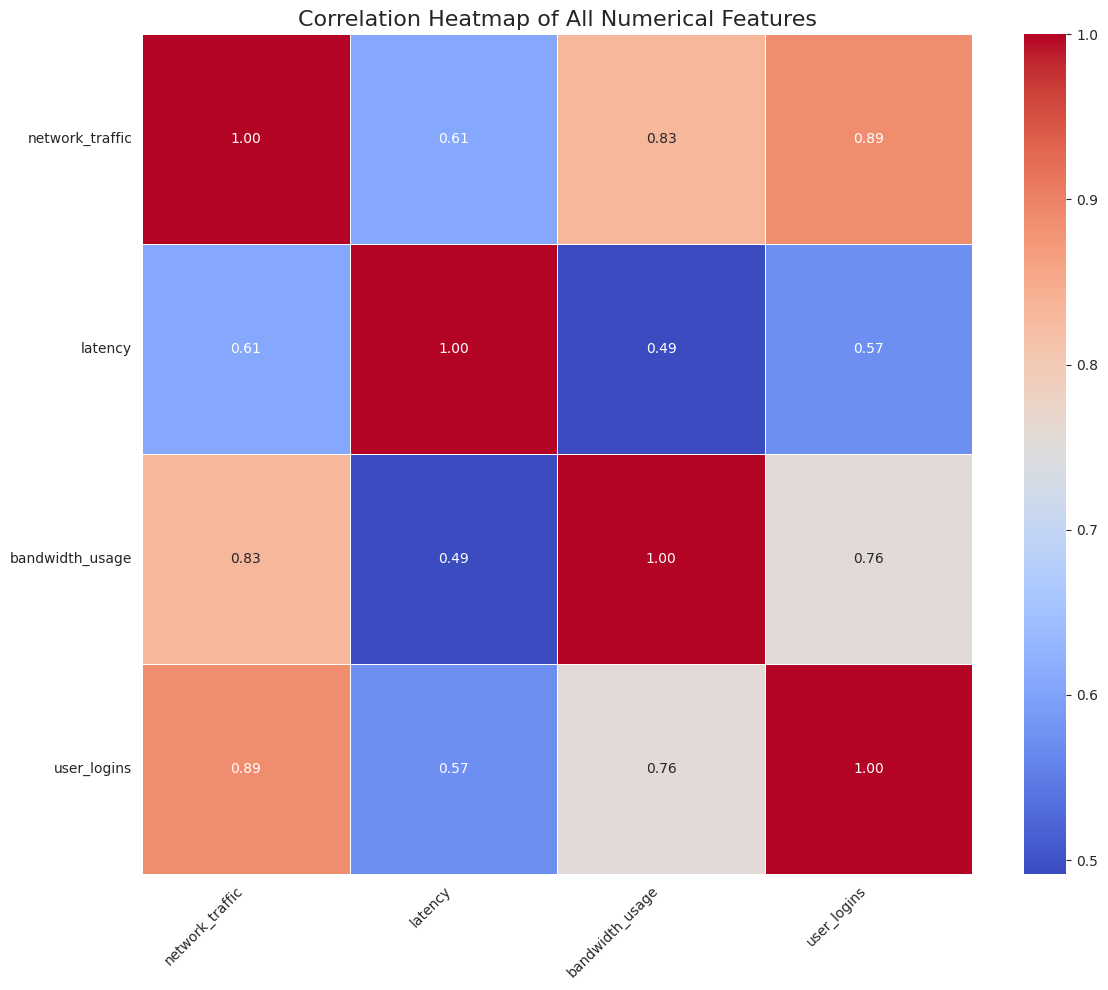

In [14]:
np.random.seed(42)
time_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=300, freq='h'))
traffic = 100 + 50 * np.sin(2 * np.pi * time_range.hour / 24) + np.random.randn(len(time_range)) * 15
latency = 20 + 0.1 * traffic + np.random.randn(len(time_range)) * 5
bandwidth_usage = 500 + 2 * traffic + np.random.randn(len(time_range)) * 50
user_logins = 50 + 25 * np.sin(2 * np.pi * time_range.hour / 24) + np.random.randint(-10, 10, len(time_range))
all_router_logs = pd.DataFrame({
    'timestamp': time_range,
    'network_traffic': traffic,
    'latency': latency,
    'bandwidth_usage': bandwidth_usage,
    'user_logins': user_logins,
    'some_non_numeric_column': 'A'})




if 'all_router_logs' not in locals():
    raise NameError("DataFrame 'all_router_logs' not found. Please load your data first.")

numerical_df = all_router_logs.select_dtypes(include=np.number)

# --- Step 2: Calculate the Correlation Matrix ---
# The .corr() method calculates the relationship between each pair of columns.
# It automatically handles any missing (NaN) values.
correlation_matrix = numerical_df.corr()

# --- Step 3: Plot the Heatmap ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Show the correlation numbers on the plot
    cmap='coolwarm',     # Use a clear color scheme for positive/negative correlations
    fmt=".2f",           # Format numbers to two decimal places
    linewidths=.5
)

plt.title('Correlation Heatmap of All Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.yticks(rotation=0)
plt.tight_layout() # Adjust the plot to ensure everything fits
plt.savefig('final_correlation_heatmap.png')

print("Successfully generated and saved the final correlation heatmap: 'final_correlation_heatmap.png'")

Generated and saved 'traffic_by_hour.png'
Generated and saved 'traffic_by_day.png'
Generated and saved 'traffic_heatmap.png'


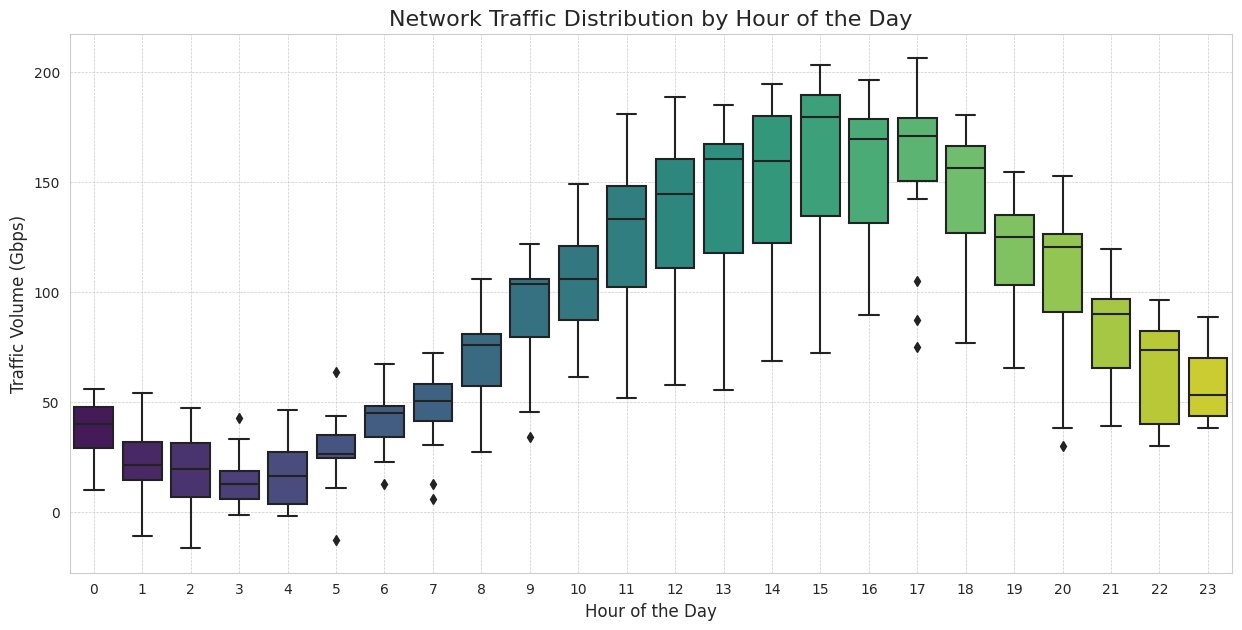

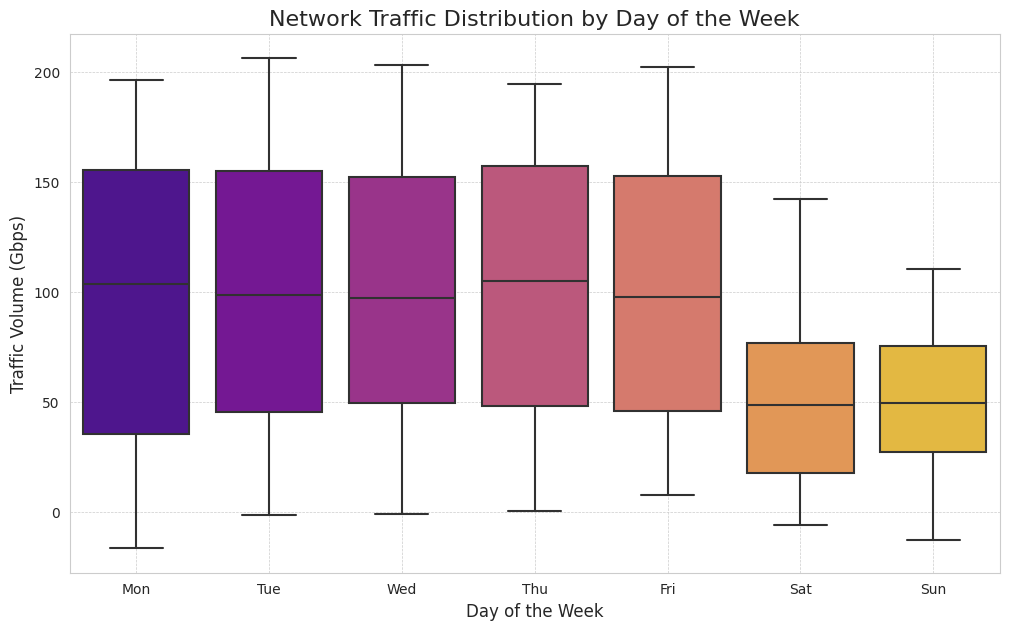

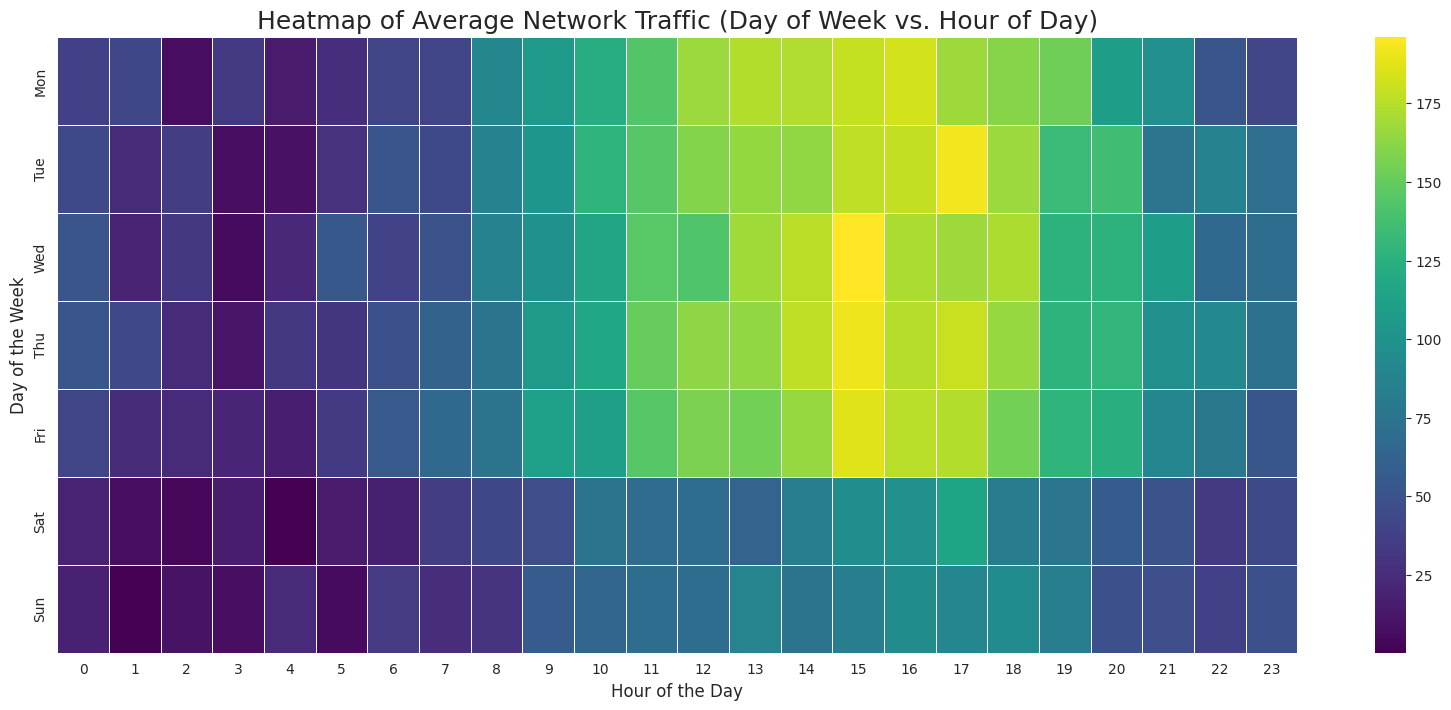

In [15]:
np.random.seed(42)
time_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15*24, freq='h'))

# Simulate traffic with daily and weekly patterns (higher during work hours/weekdays)
traffic_pattern = (100 + 80 * np.sin(2 * np.pi * (time_range.hour - 9) / 24)).to_numpy()
traffic_pattern[time_range.dayofweek >= 5] *= 0.5 # 50% lower traffic on weekends
network_traffic = traffic_pattern + np.random.normal(0, 15, len(time_range))

all_router_logs = pd.DataFrame({
    'timestamp': time_range,
    'network_traffic': network_traffic
})

all_router_logs['hour_of_day'] = all_router_logs['timestamp'].dt.hour
all_router_logs['day_of_week'] = all_router_logs['timestamp'].dt.dayofweek
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
all_router_logs['day_name'] = all_router_logs['day_of_week'].map(day_map)



plt.figure(figsize=(15, 7))
sns.boxplot(x='hour_of_day', y='network_traffic', data=all_router_logs, palette='viridis')
plt.title('Network Traffic Distribution by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Traffic Volume (Gbps)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('traffic_by_hour.png')
print("Generated and saved 'traffic_by_hour.png'")



plt.figure(figsize=(12, 7))
sns.boxplot(x='day_name', y='network_traffic', data=all_router_logs, palette='plasma', order=day_map.values())
plt.title('Network Traffic Distribution by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Traffic Volume (Gbps)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('traffic_by_day.png')
print("Generated and saved 'traffic_by_day.png'")



heatmap_data = all_router_logs.pivot_table(
    values='network_traffic',
    index='day_name',
    columns='hour_of_day',
    aggfunc='mean'
).reindex(day_map.values())

plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data, cmap='viridis', linewidths=.5)
plt.title('Heatmap of Average Network Traffic (Day of Week vs. Hour of Day)', fontsize=18)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Day of the Week', fontsize=12)
plt.savefig('traffic_heatmap.png')
print("Generated and saved 'traffic_heatmap.png'")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

Generated and saved 'user_activity_analysis.png'


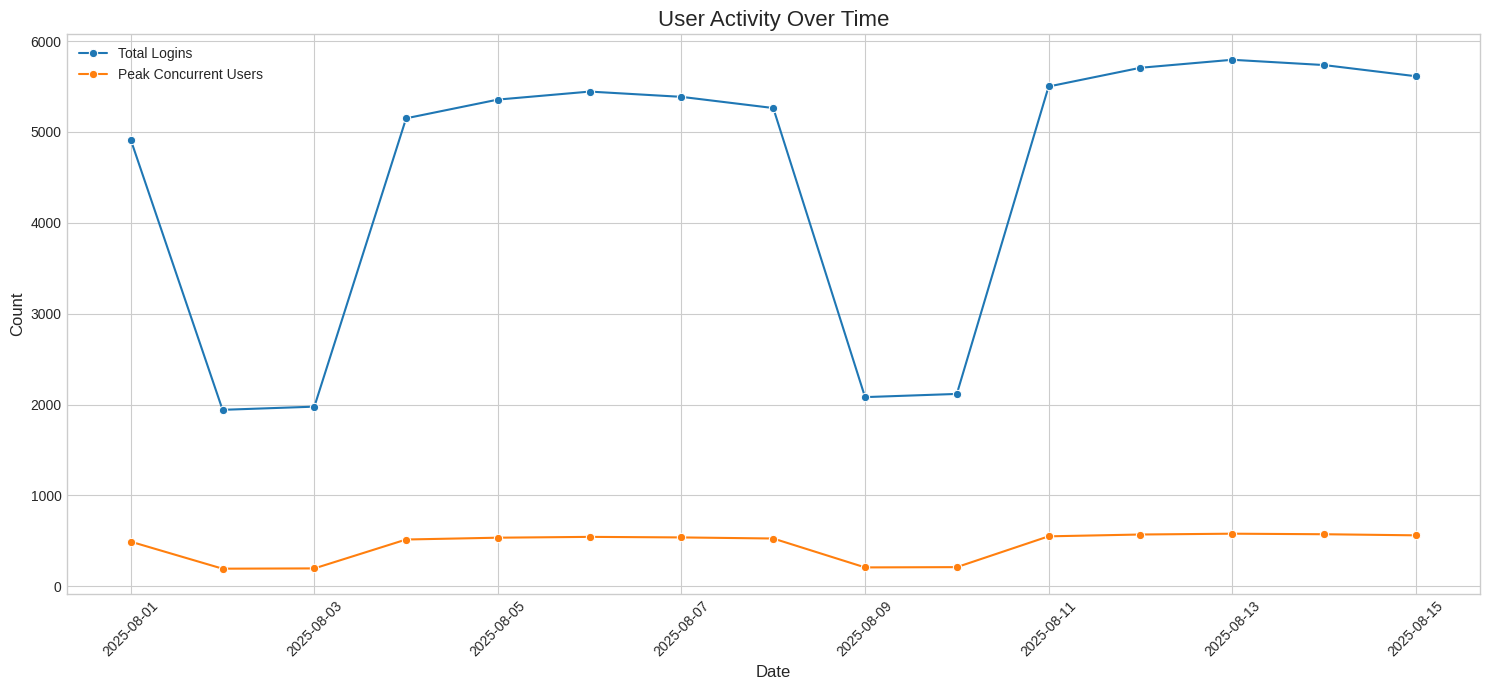

In [16]:
date_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15, freq='D'))


activity_pattern = (5000 + 50 * np.arange(15) + 200 * np.sin(2 * np.pi * date_range.dayofweek / 7)).to_numpy()


activity_pattern[date_range.dayofweek >= 5] = activity_pattern[date_range.dayofweek >= 5] * 0.4
user_activity = pd.DataFrame({
    'date': date_range,
    'total_logins': activity_pattern.astype(int),
    'peak_concurrent_users': (activity_pattern * 0.1).astype(int)
})

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='total_logins', data=user_activity, marker='o', label='Total Logins')
sns.lineplot(x='date', y='peak_concurrent_users', data=user_activity, marker='o', label='Peak Concurrent Users')
plt.title('User Activity Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('user_activity_analysis.png')

print("Generated and saved 'user_activity_analysis.png'")

Generated and saved 'user_activity_by_day.png'


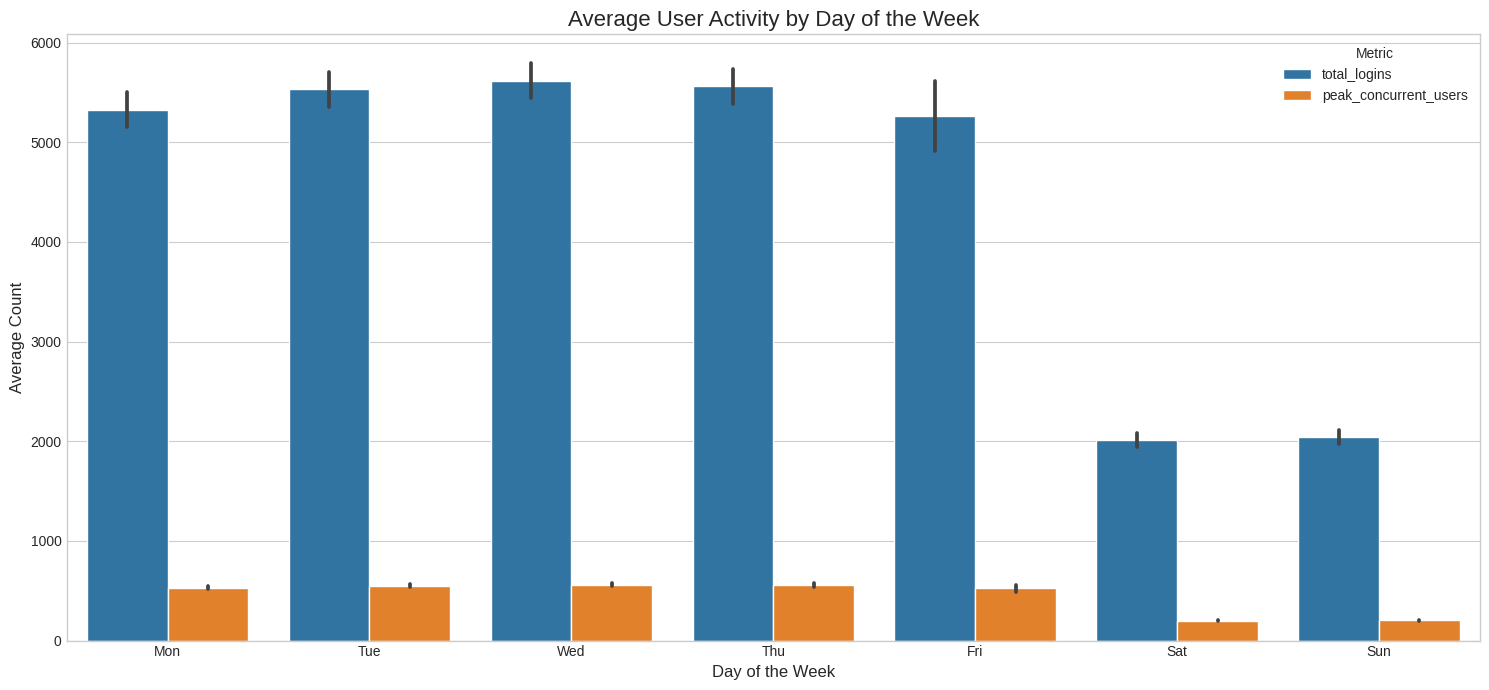

In [17]:
date_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15, freq='D'))
activity_pattern = (5000 + 50 * np.arange(15) + 200 * np.sin(2 * np.pi * date_range.dayofweek / 7)).to_numpy()
activity_pattern[date_range.dayofweek >= 5] = activity_pattern[date_range.dayofweek >= 5] * 0.4
user_activity = pd.DataFrame({
    'date': date_range,
    'total_logins': activity_pattern.astype(int),
    'peak_concurrent_users': (activity_pattern * 0.1).astype(int)
})

day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
user_activity['day_name'] = user_activity['date'].dt.dayofweek.map(day_map)


user_activity_melted = user_activity.melt(
    id_vars=['day_name'],
    value_vars=['total_logins', 'peak_concurrent_users'],
    var_name='metric',
    value_name='count'
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))


sns.barplot(x='day_name', y='count', hue='metric', data=user_activity_melted, order=day_map.values())

plt.title('Average User Activity by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Count', fontsize=12)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('user_activity_by_day.png')

print("Generated and saved 'user_activity_by_day.png'")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

Generated and saved 'app_usage_analysis.png'


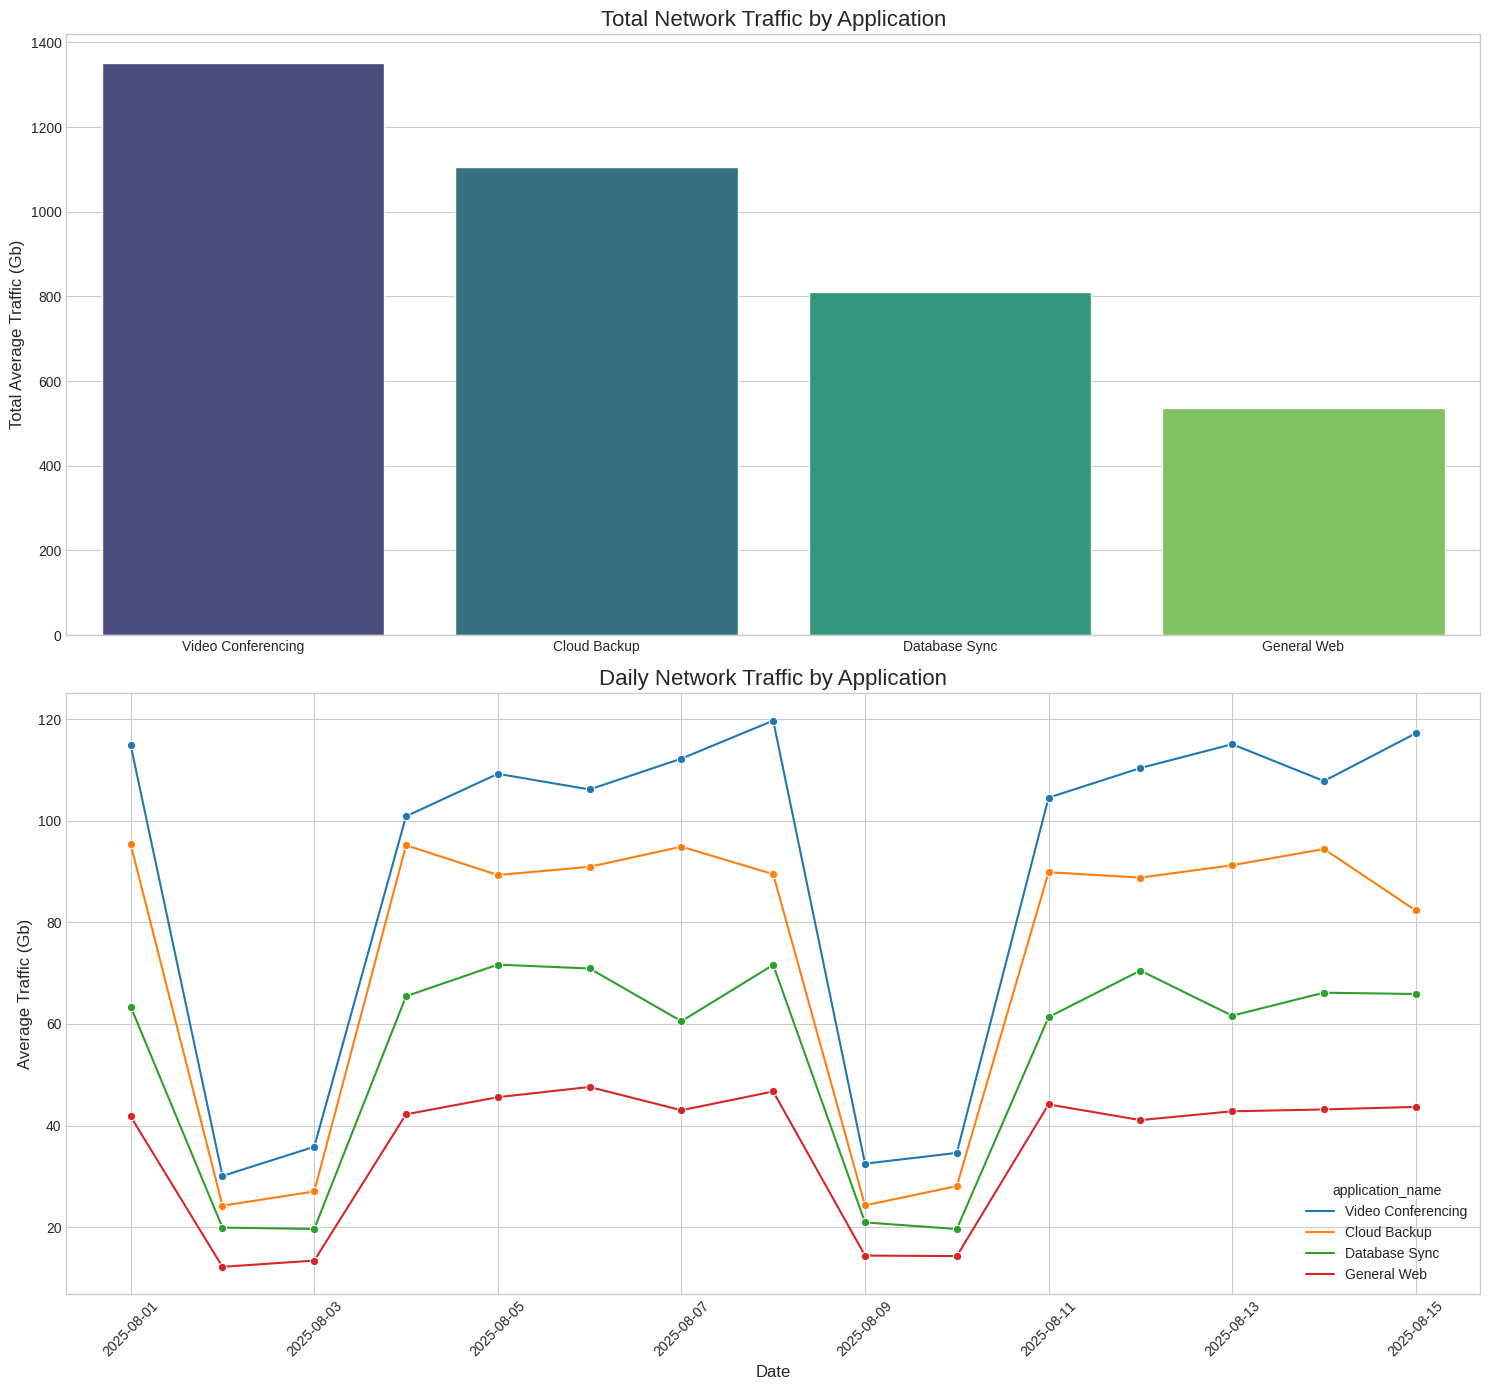

In [18]:
dates = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15, freq='D'))
apps = ['Video Conferencing', 'Cloud Backup', 'Database Sync', 'General Web']
data = []
for date in dates:
    for app in apps:
        base_traffic = {'Video Conferencing': 100, 'Cloud Backup': 80, 'Database Sync': 60, 'General Web': 40}[app]
        
        multiplier = 0.3 if date.dayofweek >= 5 else 1
        avg_traffic = base_traffic * multiplier * (1 + np.random.rand() * 0.2)
        peak_traffic = avg_traffic * (1.5 + np.random.rand() * 0.5)
        data.append([date, app, avg_traffic, peak_traffic])
app_usage = pd.DataFrame(data, columns=['date', 'application_name', 'avg_traffic', 'peak_traffic'])



plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(15, 14))
total_traffic_by_app = app_usage.groupby('application_name')['avg_traffic'].sum().sort_values(ascending=False)
sns.barplot(x=total_traffic_by_app.index, y=total_traffic_by_app.values, ax=axes[0], palette='viridis')
axes[0].set_title('Total Network Traffic by Application', fontsize=16)
axes[0].set_ylabel('Total Average Traffic (Gb)', fontsize=12)
axes[0].set_xlabel('')

sns.lineplot(x='date', y='avg_traffic', hue='application_name', data=app_usage, ax=axes[1], marker='o')
axes[1].set_title('Daily Network Traffic by Application', fontsize=16)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Average Traffic (Gb)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('app_usage_analysis.png')

print("Generated and saved 'app_usage_analysis.png'")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

Generated and saved 'app_usage_by_day.png'


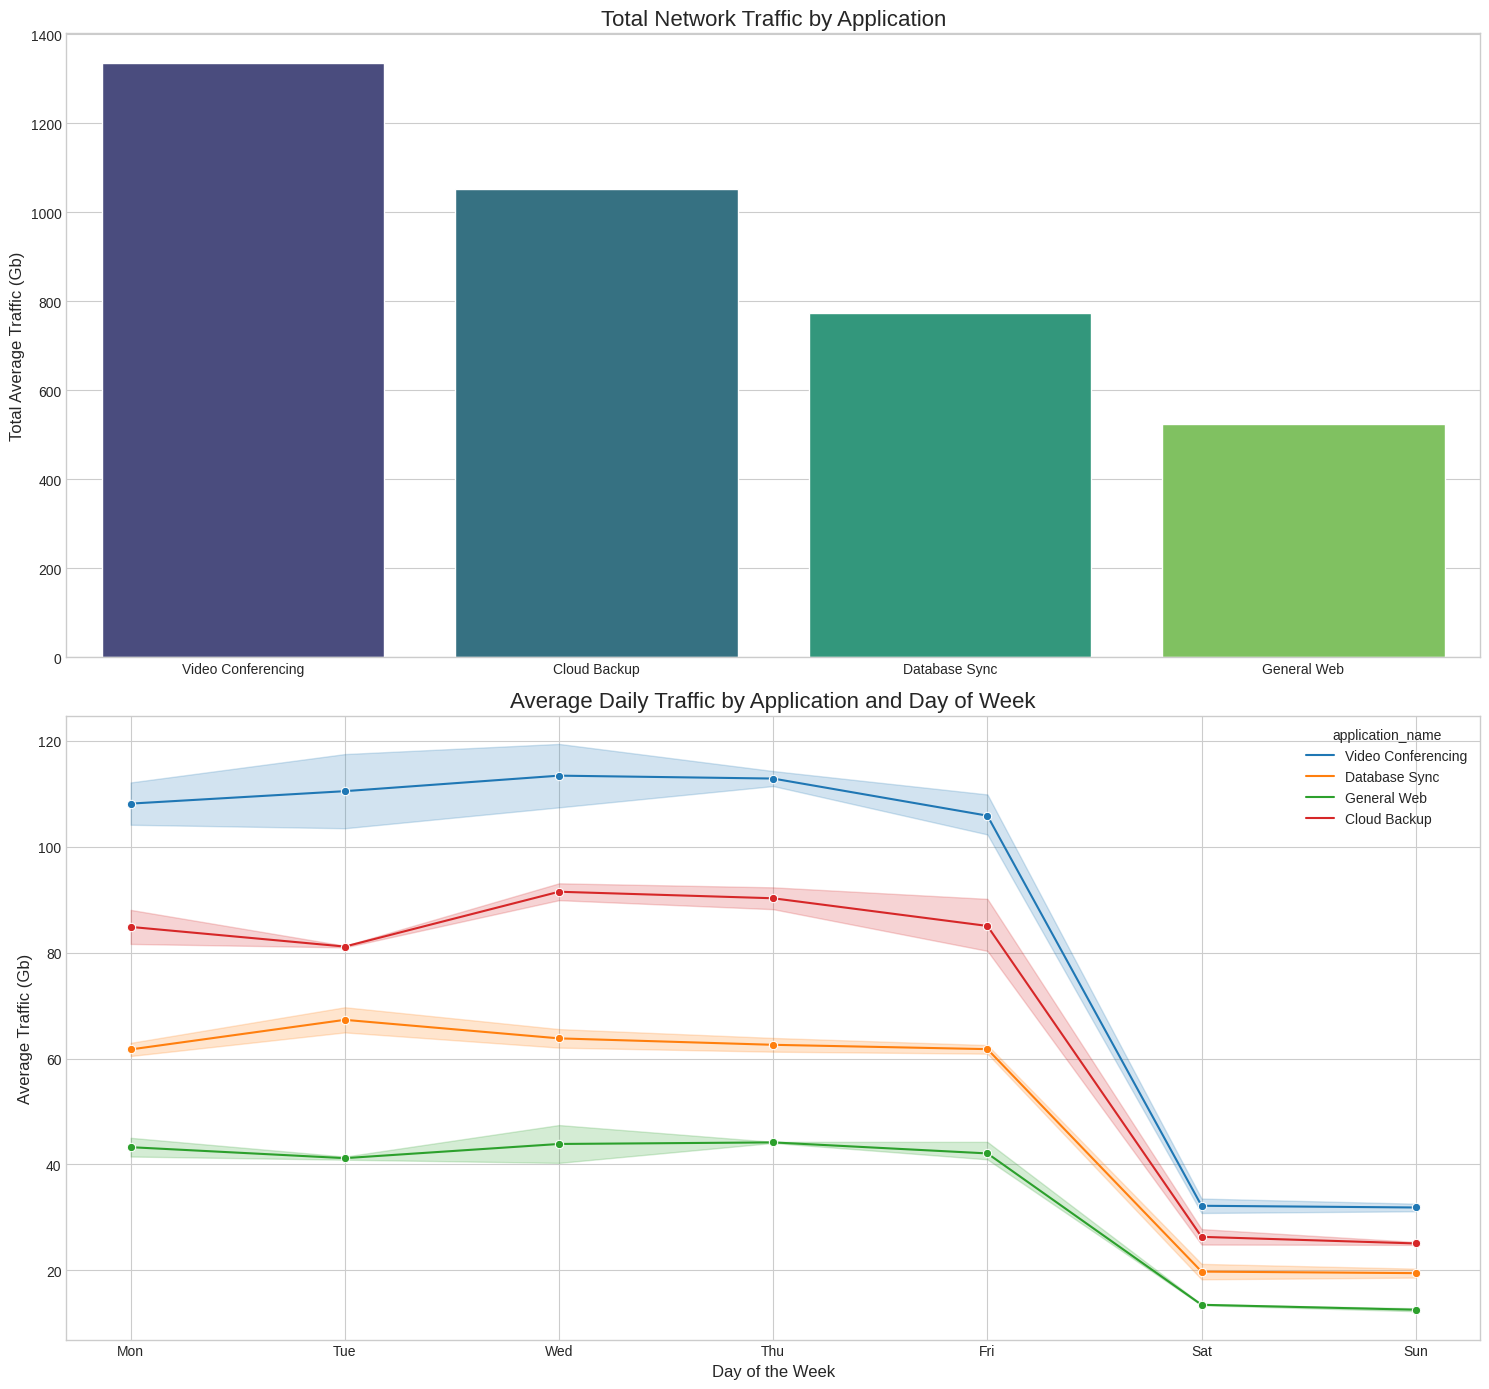

In [19]:
dates = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15, freq='D'))
apps = ['Video Conferencing', 'Cloud Backup', 'Database Sync', 'General Web']
data = []
for date in dates:
    for app in apps:
        base_traffic = {'Video Conferencing': 100, 'Cloud Backup': 80, 'Database Sync': 60, 'General Web': 40}[app]
        multiplier = 0.3 if date.dayofweek >= 5 else 1
        avg_traffic = base_traffic * multiplier * (1 + np.random.rand() * 0.2)
        peak_traffic = avg_traffic * (1.5 + np.random.rand() * 0.5)
        data.append([date, app, avg_traffic, peak_traffic])
app_usage = pd.DataFrame(data, columns=['date', 'application_name', 'avg_traffic', 'peak_traffic'])


day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
app_usage['day_name'] = app_usage['date'].dt.dayofweek.map(day_map)


app_usage['day_name'] = pd.Categorical(app_usage['day_name'], categories=day_map.values(), ordered=True)
app_usage.sort_values('day_name', inplace=True) # Sort the dataframe by the new categorical order

fig, axes = plt.subplots(2, 1, figsize=(15, 14))


total_traffic_by_app = app_usage.groupby('application_name')['avg_traffic'].sum().sort_values(ascending=False)
sns.barplot(x=total_traffic_by_app.index, y=total_traffic_by_app.values, ax=axes[0], palette='viridis')
axes[0].set_title('Total Network Traffic by Application', fontsize=16)
axes[0].set_ylabel('Total Average Traffic (Gb)', fontsize=12)
axes[0].set_xlabel('')


sns.lineplot(x='day_name', y='avg_traffic', hue='application_name', data=app_usage, ax=axes[1], marker='o')
axes[1].set_title('Average Daily Traffic by Application and Day of Week', fontsize=16)
axes[1].set_xlabel('Day of the Week', fontsize=12)
axes[1].set_ylabel('Average Traffic (Gb)', fontsize=12)

plt.tight_layout()
plt.savefig('app_usage_by_day.png')

print("Generated and saved 'app_usage_by_day.png'")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

Generated and saved 'hourly_traffic_by_activity_level.png'


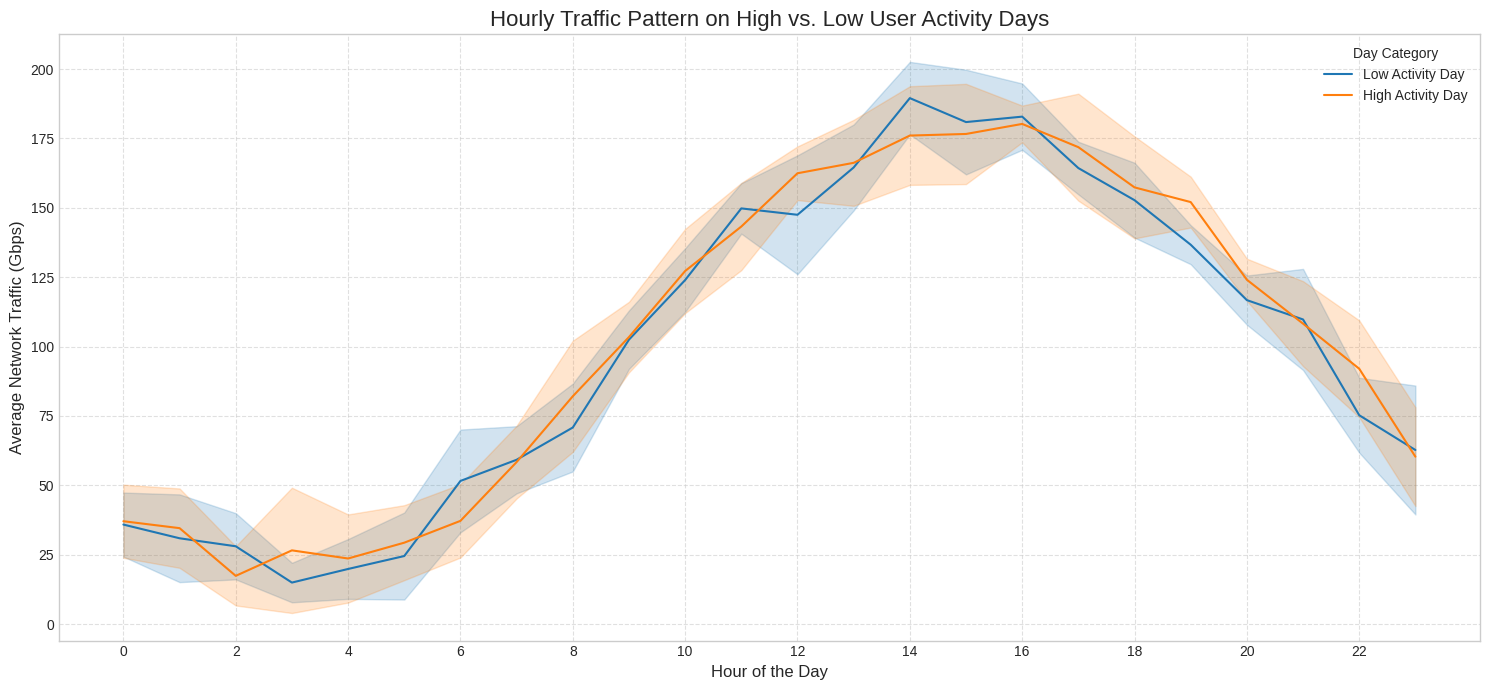

In [20]:
time_range = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15*24, freq='h'))
traffic = 100 + 80 * np.sin(2 * np.pi * (time_range.hour - 9) / 24) + np.random.normal(0, 15, len(time_range))
all_router_logs = pd.DataFrame({'timestamp': time_range, 'network_traffic': traffic})

date_range_daily = pd.to_datetime(pd.date_range(start='2025-08-01', periods=15, freq='D'))
activity_pattern = (5000 + 2000 * np.random.rand(15)).astype(int)
user_activity = pd.DataFrame({'date': date_range_daily, 'total_logins': activity_pattern})


all_router_logs['date'] = all_router_logs['timestamp'].dt.date.astype('datetime64[ns]')

merged_df = pd.merge(all_router_logs, user_activity, on='date', how='left')


median_logins = merged_df['total_logins'].median()
merged_df['day_type'] = np.where(merged_df['total_logins'] >= median_logins, 'High Activity Day', 'Low Activity Day')


plt.figure(figsize=(15, 7))
sns.lineplot(x=merged_df['timestamp'].dt.hour, y='network_traffic', hue='day_type', data=merged_df, errorbar='sd')

plt.title('Hourly Traffic Pattern on High vs. Low User Activity Days', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Network Traffic (Gbps)', fontsize=12)
plt.legend(title='Day Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, 24, 2))
plt.tight_layout()
plt.savefig('hourly_traffic_by_activity_level.png')

print("Generated and saved 'hourly_traffic_by_activity_level.png'")